In [ ]:
#Retail_Stores_Inventory Analysis
#Author: Serena Wang

# Sales Inventory Cleaning & Exploratory Data Analysis

## 1. Business Understanding

Project Objective

This project aims to analyze retail inventory and sales patterns across stores and products. The goal is to identify sales trends, inventory behaviors, and factors affecting demand in order to support inventory optimization.

Dataset Granularity

Each record represents inventory and sales information for a specific product at a particular store on a given date.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

In [4]:
df = pd.read_csv("./retail_store_inventory.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022/1/1,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022/1/1,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022/1/1,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022/1/1,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022/1/1,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## 3. Schema Review

In [5]:
df.shape

(73100, 15)

In [7]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


In [9]:
df['Date'].nunique()

731

In [10]:
df['Store ID'].nunique()

5

In [11]:
df['Product ID'].nunique()

20


Schema Review - Observations

* The dataset contains 73,100 observations and 15 variables.
* No missing values were detected.
* The dataset consists of 7 categorical variables, 5 integer variables, and 3 floating-point variables.
* The Date column is currently stored as a string and requires conversion to datetime format.
* The dataset spans 731 days, covering approximately two years of historical records.
* Five stores and twenty products are included.
* Each record represents sales and inventory information for a specific product in a particular store on a given date.

## 4. Data Dictionary

In [19]:
dictionary = pd.DataFrame({

"Column":[
"Date",
"Store ID",
"Product ID",
"Category",
"Region",
"Inventory Level",
"Units Sold",
"Units Ordered",
"Demand Forecast",
"Price",
"Discount",
"Holiday/Promotion",
"Competitor Pricing",
"Weather Condition",
"Seasonality"
],

"Type":[
"datetime",
"string",
"string",
"string",
"string",
"int",
"int",
"int",
"float",
"float",
"int",
"bool",
"float",
"string",
"string"
],

"Cleaning Notes":[
"Converted from string",
"No changes",
"No changes",
"No changes",
"No changes",
"No changes",
"Investigate outliers",
"No changes",
"Negative values retained",
"No changes",
"Validate values",
"Converted from int",
"No changes",
"No changes",
"No changes"
]

})

dictionary

,Column,Type,Cleaning Notes
0,Date,datetime,Converted from string
1,Store ID,string,No changes
2,Product ID,string,No changes
3,Category,string,No changes
4,Region,string,No changes
5,Inventory Level,int,No changes
6,Units Sold,int,Investigate outliers
7,Units Ordered,int,No changes
8,Demand Forecast,float,Negative values retained
9,Price,float,No changes


## 5. Data Type Validation

In [20]:
df["Date"]=pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [21]:
df["Holiday/Promotion"]=df["Holiday/Promotion"].astype(bool)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  bool          
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [15]:
df["Weather Condition"].unique()

<StringArray>
['Rainy', 'Sunny', 'Cloudy', 'Snowy']
Length: 4, dtype: str

## 6. Duplicate Detection

In [12]:
df.duplicated().sum()

np.int64(0)

## 7. Descriptive Statistics

In [25]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,26.191408


Observations

- Inventory Level

Inventory levels appear relatively evenly distributed since the mean and median are very close.


- Units Sold

Units Sold exhibits a positively skewed distribution, as the mean exceeds the median.

- Demand Forecast

Demand Forecast contains negative values, which are unrealistic in retail operations and may indicate synthetic data generation artifacts.


- Price

Product prices range from $10 to $100, with an average price of approximately $55.


## 8. Distribution Analysis (EDA)

{'whiskers': [<matplotlib.lines.Line2D at 0x23d84ed39e0>,
 'caps': [<matplotlib.lines.Line2D at 0x23d84ed3f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x23d84dc4e00>],
 'medians': [<matplotlib.lines.Line2D at 0x23d84f045f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x23d84f048f0>],
 'means': []}

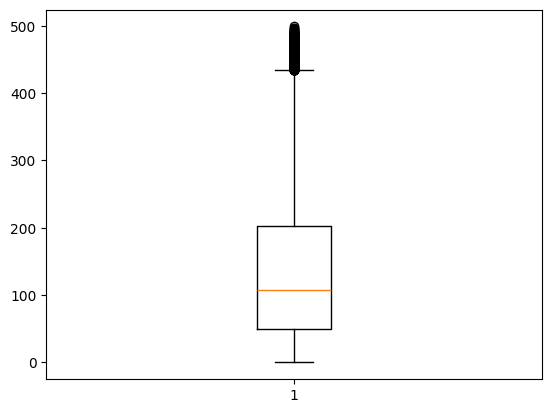

In [9]:
plt.boxplot(df["Units Sold"])

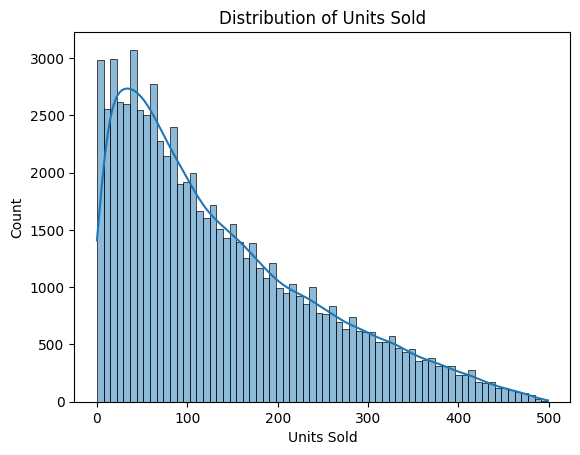

In [23]:
sns.histplot(df["Units Sold"],kde=True)
plt.title("Distribution of Units Sold")
plt.show()

Units Sold demonstrates a positively skewed distribution characterized by a long right tail.

## 9. Outlier Detection

In [27]:
Q1=df["Units Sold"].quantile(0.25)
Q3=df["Units Sold"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
outliers=df[(df["Units Sold"]<lower)|(df["Units Sold"]>upper)]
len(outliers)

715

## 10.Time Series Validation

In [6]:
df["Date"].min()

'2022/1/1'

In [7]:
df["Date"].max()

'2024/1/1'

In [29]:
daily_sales=df.groupby("Date")["Units Sold"].sum()
daily_sales.head()

Date
2022-01-01    14484
2022-01-02    13415
2022-01-03    13681
2022-01-04    14084
2022-01-05    12572
Name: Units Sold, dtype: int64

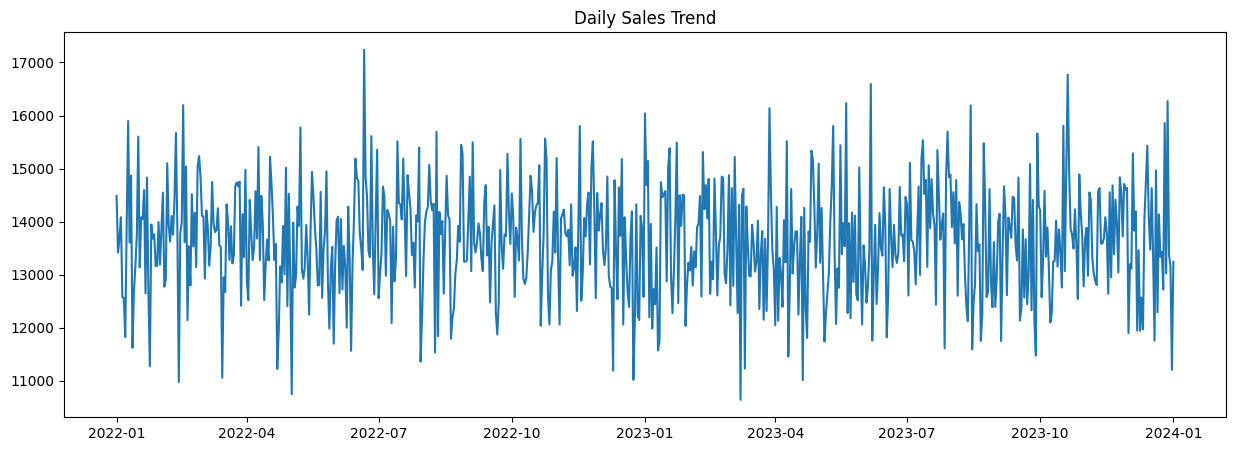

In [30]:
plt.figure(figsize =(15,5))
plt.plot(daily_sales)
plt.title("Daily Sales Trend")
plt.show()

## 11.Category Analysis

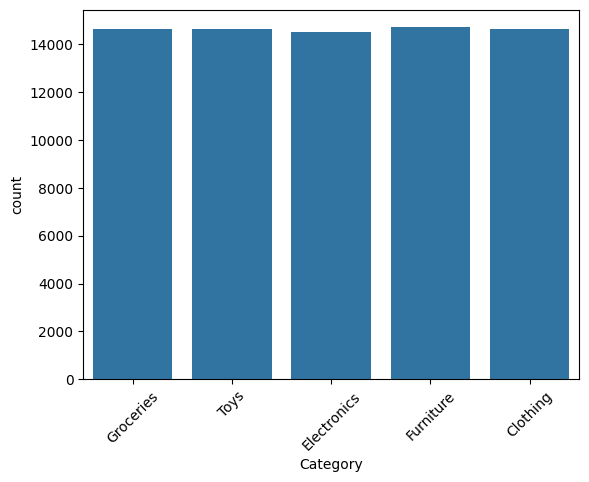

In [31]:
df["Category"].value_counts()
sns.countplot(data=df,x="Category")
plt.xticks(rotation=45)
plt.show()

## 12.Correlation Analysis

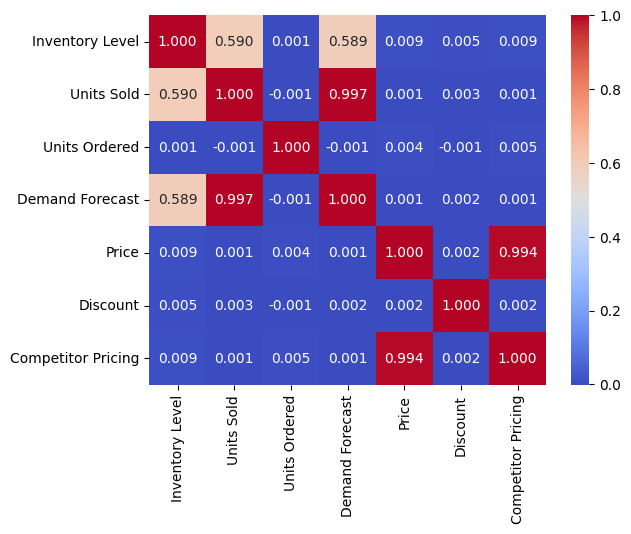

In [34]:
corr = df.select_dtypes(include = np.number).corr()
sns.heatmap(corr,
           annot =True,
           cmap = "coolwarm",
           fmt=".3f")
plt.show()

Observations
- Demand Forecast is almost perfectly correlated with Units Sold, suggesting that the forecast variable may have been generated directly from historical sales.
- Competitor Pricing exhibits an extremely strong positive correlation with product prices, indicating that competitor prices closely follow the company's pricing strategy.
- Discounts appears to have little association with sales volume in this dataset.

## 13.Feature Engineering

### 13.1 Time-based Features

Additional calendar attributes were created to facilitate seasonality analysis and temporal trend exploration.

In [37]:
#Time Features
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Quarter"] =df["Date"].dt.quarter
df["Weekday"] =df["Date"].dt.day_name()
df["Week"]=df["Date"].dt.isocalendar().week

 ### 13.2 Inventory Features

Inventory-related metrics were engineered to assess stock efficiency and potential stockout risks.

In [38]:
#Inventory Features
df["Inventory Turnover"] = df["Units Sold"]/df["Inventory Level"]

In [40]:
df["Stockout Risk"] =(
    df["Demand Forecast"]>df["Inventory Level"]
).astype(int)

### 13.3 Pricing Features

Pricing indicators were generated to evaluate competitiveness and pricing strategies.

In [41]:
#Pricing Features
df["Price Gap"]=(
    df["Competitor Pricing"]-df["Price"]
)

In [42]:
df["Proce Ratio"]=(
    df["Price"]/df["Competitor Pricing"]
)

### 13.4 Promotion Features

A binary indicator was created to identify promotional periods.

In [43]:
#Promotion Features
df["Promotion Active"]=(
    (df["Discount"]>0)|(df["Holiday/Promotion"]==1)
).astype(int)

## 14 Business Analysis

### 14.1 Seasonality Analisis

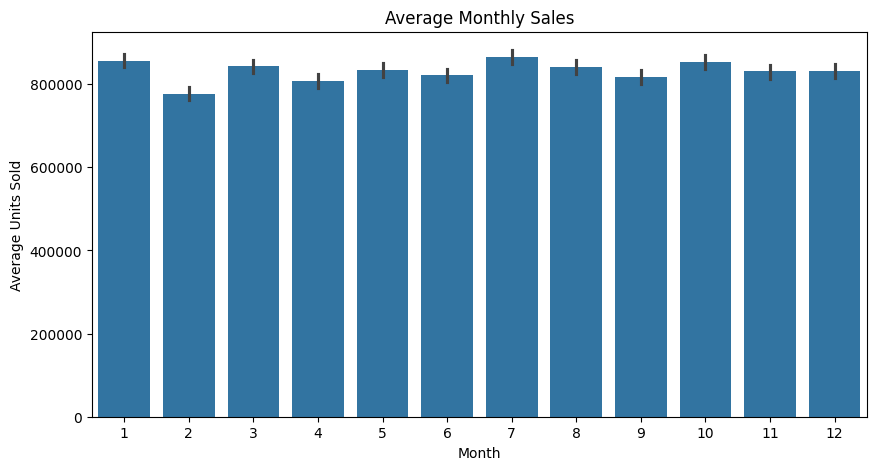

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="Month",
    y="Units Sold",
    estimator=sum
)
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.show()

No clear seasonality pattern is observed.

### 14.2 Inventory Analysis

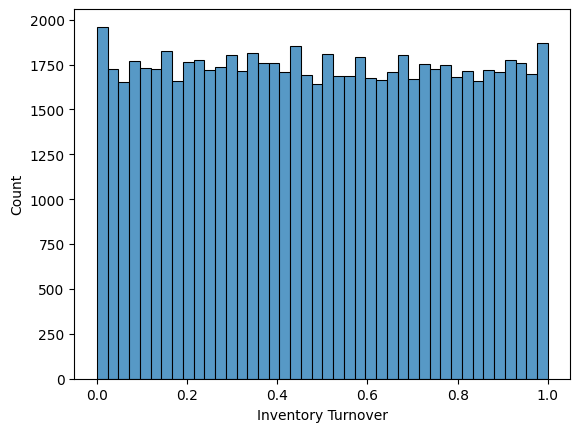

In [52]:
sns.histplot(df["Inventory Turnover"])
plt.show()

In [55]:
df["Stockout Risk"].value_counts()

Stockout Risk
0    70515
1     2585
Name: count, dtype: int64

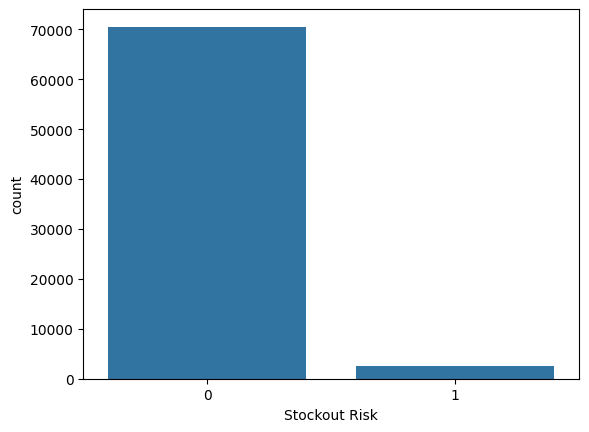

In [54]:
sns.countplot(data=df,x="Stockout Risk")
plt.show()

### 14.3 Inventory Turnover

In [61]:
# Inventory Turnover

turnover =( df.groupby(
    ["Store ID","Product ID"]
).agg({
    "Units Sold":"sum",
    "Inventory Level":"mean"
}).reset_index()
          )

turnover["Inventory Turnover"]=(
    turnover["Units Sold"]/turnover["Inventory Level"]
)

turnover.sort_values(
    "Inventory Turnover",
    ascending =False
).head(10)

,Store ID,Product ID,Units Sold,Inventory Level,Inventory Turnover
94,S005,P0015,109099,277.906977,392.573808
39,S002,P0020,105343,276.309166,381.250473
20,S002,P0001,105999,278.343365,380.821005
44,S003,P0005,105408,277.566347,379.757852
31,S002,P0012,102528,271.630643,377.453732
56,S003,P0017,104566,277.150479,377.289624
65,S004,P0006,103147,273.597811,377.002285
52,S003,P0013,107479,285.261286,376.773875
37,S002,P0018,102482,272.025992,376.736059
2,S001,P0003,103393,274.543092,376.600261


In [59]:
print(df.index)
print(df.columns)

RangeIndex(start=0, stop=73100, step=1)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Year', 'Month', 'Quarter',
       'Weekday', 'Week', 'Inventory Turnover', 'Stockout Risk', 'Price Gap',
       'Proce Ratio', 'Promotion Active'],
      dtype='str')


### 14.4 Price Gap

In [62]:
df["Price Gap"] = (
    df["Competitor Pricing"] - df["Price"]
)
df["Price Gap"].describe()

count    73100.000000
mean         0.010969
std          2.888538
min         -5.000000
25%         -2.500000
50%          0.000000
75%          2.530000
max          5.000000
Name: Price Gap, dtype: float64

## 15 Time Series Analysis

### 15.1 Monthly Demand Trend

In [64]:
monthly_sales =(
    df.groupby(
        pd.Grouper(
            key="Date",freq="ME"
        )
    )["Units Sold"].sum().reset_index()
)

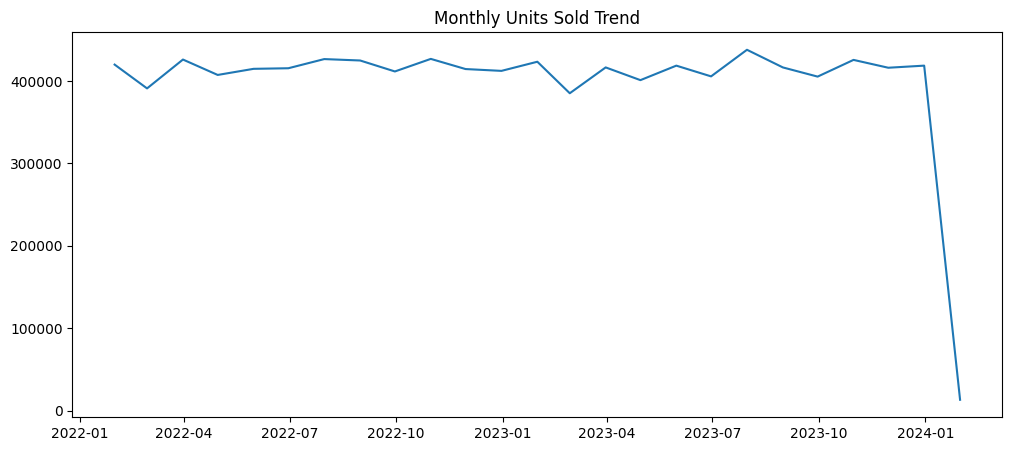

In [65]:
plt.figure(figsize=(12,5))
plt.plot(
monthly_sales["Date"],
monthly_sales["Units Sold"]
)
plt.title(
"Monthly Units Sold Trend"
)
plt.show()

### 15.2 Month-over-Month Growth

In [71]:
df["Month"]=df["Date"].dt.month
df["Year"]=df["Date"].dt.year
Monthly_sales=(
df.groupby(
["Year","Month"]
)["Units Sold"].sum().reset_index()
)

In [72]:
Monthly_sales["MoM Growth"]=(
Monthly_sales["Units Sold"].pct_change()*100
)

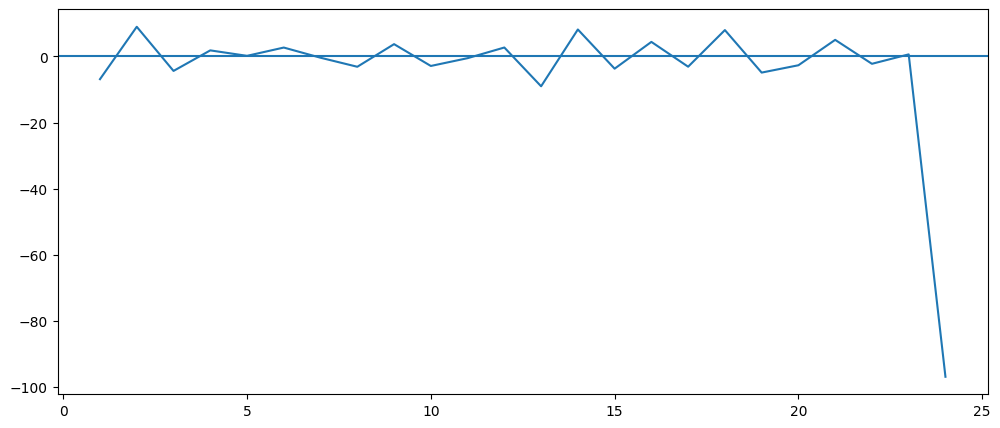

In [73]:
plt.figure(figsize=(12,5))
plt.plot(
Monthly_sales.index,
Monthly_sales["MoM Growth"]
)
plt.axhline(0)
plt.show()

### 15.3 Monthly Sales by Category

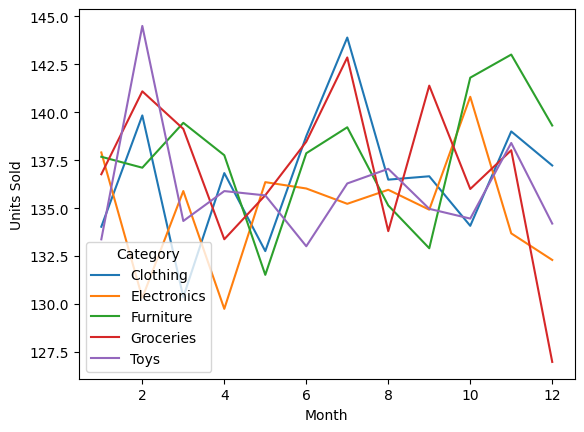

In [69]:
monthly_category=(
df.groupby(
["Month","Category"]
)
["Units Sold"].mean().reset_index()
)
sns.lineplot(
data=monthly_category,
x="Month",
y="Units Sold",
hue="Category"
)
plt.show()

### 15.4 Monthly Sales by Region

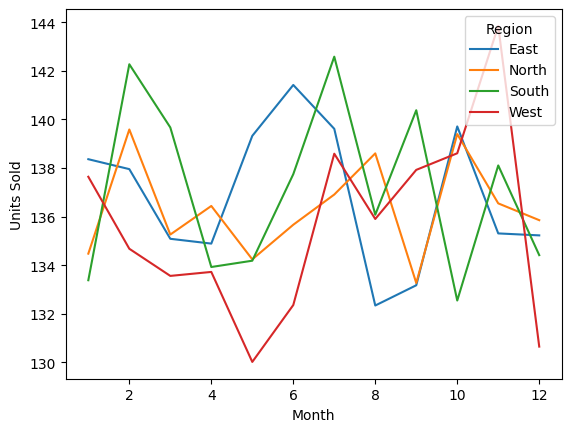

In [70]:
monthly_region=(
df.groupby(
["Month","Region"]
)
["Units Sold"]
.mean()
.reset_index()
)
sns.lineplot(
data=monthly_region,
x="Month",
y="Units Sold",
hue="Region"
)
plt.show()

## Conclution


This project demonstrates an end-to-end exploratory data analysis workflow, including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- KPI Calculation
- Time Series Aggregation
- Data Quality Assessment

Limitations

This dataset appears to be synthetically generated and exhibits several unrealistic characteristics:

- Demand Forecast is almost perfectly correlated with Units Sold.
- Competitor prices differ from our prices by only a narrow range.
- Inventory turnover values exceed realistic industry benchmarks.
- Categories and stores are nearly uniformly distributed.